In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lukebarousse/data-analyst-job-postings-google-search/gsearch_jobs.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/lukebarousse/data-analyst-job-postings-google-search/gsearch_jobs.csv")

print(df.head(5))

   Unnamed: 0  index                                             title  \
0           0      0                                      Data Analyst   
1           1      1                                      Data Analyst   
2           2      2                         Aeronautical Data Analyst   
3           3      3  Data Analyst - Consumer Goods - Contract to Hire   
4           4      4               Data Analyst | Workforce Management   

                 company_name            location           via  \
0                        Meta           Anywhere   via LinkedIn   
1                         ATC    United States     via LinkedIn   
2  Garmin International, Inc.       Olathe, KS       via Indeed   
3                      Upwork           Anywhere     via Upwork   
4                Krispy Kreme    United States     via LinkedIn   

                                         description  \
0  In the intersection of compliance and analytic...   
1  Job Title: Entry Level Business Analy

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           61953 non-null  int64  
 1   index                61953 non-null  int64  
 2   title                61953 non-null  object 
 3   company_name         61953 non-null  object 
 4   location             61916 non-null  object 
 5   via                  61944 non-null  object 
 6   description          61953 non-null  object 
 7   extensions           61953 non-null  object 
 8   job_id               61953 non-null  object 
 9   thumbnail            38194 non-null  object 
 10  posted_at            61763 non-null  object 
 11  schedule_type        61707 non-null  object 
 12  work_from_home       27980 non-null  object 
 13  salary               10088 non-null  object 
 14  search_term          61953 non-null  object 
 15  date_time            61953 non-null 

In [4]:
print(df.isnull().sum())

Unnamed: 0                 0
index                      0
title                      0
company_name               0
location                  37
via                        9
description                0
extensions                 0
job_id                     0
thumbnail              23759
posted_at                190
schedule_type            246
work_from_home         33973
salary                 51865
search_term                0
date_time                  0
search_location            0
commute_time           61953
salary_pay             51865
salary_rate            51865
salary_avg             51865
salary_min             52441
salary_max             52441
salary_hourly          56053
salary_yearly          57884
salary_standardized    51865
description_tokens         0
dtype: int64


In [6]:
nan_salary_job = df[df['salary'].isna()]['title']
print(nan_salary_job)

1                                             Data Analyst
2                                Aeronautical Data Analyst
5                                             Data Analyst
6                          Data Analyst (Model Validation)
7                                             Data Analyst
                               ...                        
61943                                         Data Analyst
61944                        Lead FP&A Analyst- Remote, US
61945                                Data Analyst - Remote
61946    senior data analyst (business & growth)- Hybri...
61947                                      Sr Data Analyst
Name: title, Length: 51865, dtype: object


In [8]:
null_counts = df['salary'].isna().groupby(df['title']).sum()
print(null_counts)

title
!! Business Data Analyst                                                                        1
"Calling All Analytics Wizards: Recruiting Agencies with Data...                                1
"Data Analyst - Spatial Trend, Sens Slope, Spatial Correlation, ...                             2
"Data Analyst"                                                                                  1
"Data Analyst/Excel Expert"                                                                     1
                                                                                               ..
客服运营部 Customer Data Analyst intern                                                              2
📊 Data Analyst-Business                                                                         1
🔎 Google Analytics & GTM Expert - Contract to Hire                                              0
🚀 Exciting Opportunity: SAP Data Analyst (Contract) 🚀                                           2
🚨 Job Opportun

In [9]:
# Basic statistics for the salary columns
salary_stats = df[['salary_avg', 'salary_min', 'salary_max']].describe()

salary_stats

,salary_avg,salary_min,salary_max
count,10088.000000,9512.000000,9512.000000
mean,42100.231239,34846.281874,50487.856787
std,55893.993519,45843.034891,67366.522273
min,7.250000,8.000000,10.000000
25%,31.500000,19.520000,45.000000
50%,60.000000,50.000000,75.000000
75%,92500.000000,77000.000000,110000.000000
max,550000.000000,450000.000000,850000.000000


In [10]:
# Separating the data into hourly and yearly salary postings
hourly_jobs = df[df['salary_hourly'].notnull()]
yearly_jobs = df[df['salary_yearly'].notnull()]

# Basic statistics for hourly and yearly salary postings
hourly_salary_stats = hourly_jobs[['salary_avg', 'salary_min', 'salary_max']].describe()
yearly_salary_stats = yearly_jobs[['salary_avg', 'salary_min', 'salary_max']].describe()

hourly_salary_stats, yearly_salary_stats

(        salary_avg   salary_min   salary_max
 count  5900.000000  5522.000000  5522.000000
 mean     40.539588    29.301688    52.264401
 std      22.214540    18.474025    29.946964
 min       7.250000     8.000000    10.000000
 25%      23.265000    16.000000    30.000000
 50%      33.500000    20.000000    47.000000
 75%      55.000000    40.000000    70.000000
 max     300.000000   200.000000   500.000000,
           salary_avg     salary_min     salary_max
 count    4069.000000    3874.000000    3874.000000
 mean   104115.406718   85331.449773  123660.749130
 std     36024.388492   29301.473786   45902.176146
 min     29289.840000   19000.000000   35000.000000
 25%     80000.180000   67100.000000   94035.000000
 50%     96500.000000   77884.500000  116000.000000
 75%    120000.000000  100000.000000  140462.000000
 max    550000.000000  450000.000000  850000.000000)

In [14]:
#Most Demanded Skills
skills = df["description_tokens"].str.split(",")

skills_series = skills.explode()

top_skills = skills_series.value_counts().head(10)

print(top_skills)

description_tokens
 'sql'         14217
 'sql']        14025
[]             13352
 'python'      10183
 'excel'        9462
 'r'            9217
 'tableau'      8755
 'power_bi'     8589
['power_bi'     7742
 'python']      7431
Name: count, dtype: int64


In [15]:
# Extracting and counting the skills from the description_tokens column
skills_series = df['description_tokens'].dropna().explode()
skills_count = skills_series.value_counts()

# Displaying the top 20 most frequently required skills
top_skills = skills_count.head(20)
top_skills

description_tokens
[]                                             13352
['excel']                                       2215
['sql']                                         2058
['excel', 'sql']                                1011
['tableau', 'sql']                               419
['go']                                           406
['tableau']                                      391
['spreadsheet']                                  357
['python']                                       354
['power_bi']                                     348
['python', 'sql']                                340
['power_bi', 'python']                           338
['power_bi', 'sql']                              334
['excel', 'power_bi']                            286
['tableau', 'jira', 'sql', 'microstrategy']      272
['r', 'python', 'sql']                           270
['powerpoint', 'excel']                          252
['r']                                            251
['sap']                    

In [16]:
# Counting the occurrences of each company
company_counts = df['company_name'].value_counts()

# Displaying the top 20 companies with the most job postings
top_companies = company_counts.head(20)
top_companies

company_name
Upwork                              7533
Talentify.io                        2118
Walmart                             1829
vmysmartpros                        1415
Dice                                 862
EDWARD JONES                         747
Corporate                            612
Cox Communications                   538
Insight Global                       483
iSay                                 353
MYSMARTPROS                          266
Centene Corporation                  242
ATC                                  199
Harnham                              171
Staffigo Technical Services, LLC     167
Apex Systems                         163
Leidos                               151
Saint Louis County Clerks Office     138
CareerBuilder                        136
Sam's Club                           136
Name: count, dtype: int64

In [17]:
# Counting the occurrences of each source/platform
source_counts = df['via'].value_counts()

# Displaying the top sources/platforms
top_sources = source_counts.head(20)
top_sources

via
via LinkedIn                  20475
via Upwork                     7261
via BeBee                      5378
via Trabajo.org                3017
BeBee                          2937
via ZipRecruiter               2878
LinkedIn                       1924
via Indeed                     1849
Mysmartpros                    1417
via Snagajob                    970
via Jobs Trabajo.org            810
via Adzuna                      757
via Built In                    616
via Jora                        411
via Ai-Jobs.net                 350
via Monster                     340
ZipRecruiter                    293
via My ArkLaMiss Jobs           283
USA Remote Job Mysmartpros      259
via SimplyHired                 252
Name: count, dtype: int64

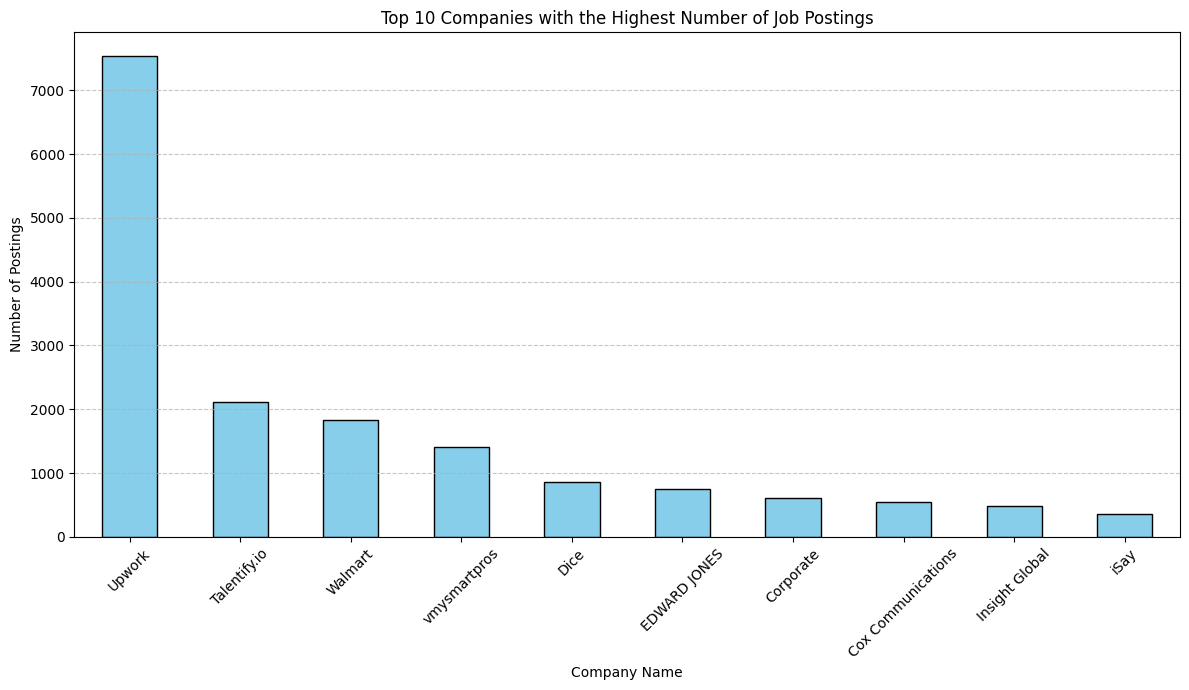

In [19]:
# Bar Chart: Top companies with the highest number of job postings
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
top_companies.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Companies with the Highest Number of Job Postings')
plt.xlabel('Company Name')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# List of potential job types and benefits to extract
job_attributes = ["Full-time", "Part-time", "Contractor", "Temporary", 
                  "Internship", "Work from home", "Health insurance", 
                  "Dental insurance", "Paid time off", "Remote"]

# Extracting and counting the occurrences of each job attribute
job_attributes_counts = {attr: df['extensions'].apply(lambda x: attr in str(x)).sum() for attr in job_attributes}

job_attributes_counts

{'Full-time': np.int64(47309),
 'Part-time': np.int64(2555),
 'Contractor': np.int64(12944),
 'Temporary': np.int64(0),
 'Internship': np.int64(835),
 'Work from home': np.int64(27980),
 'Health insurance': np.int64(21078),
 'Dental insurance': np.int64(13892),
 'Paid time off': np.int64(13724),
 'Remote': np.int64(0)}

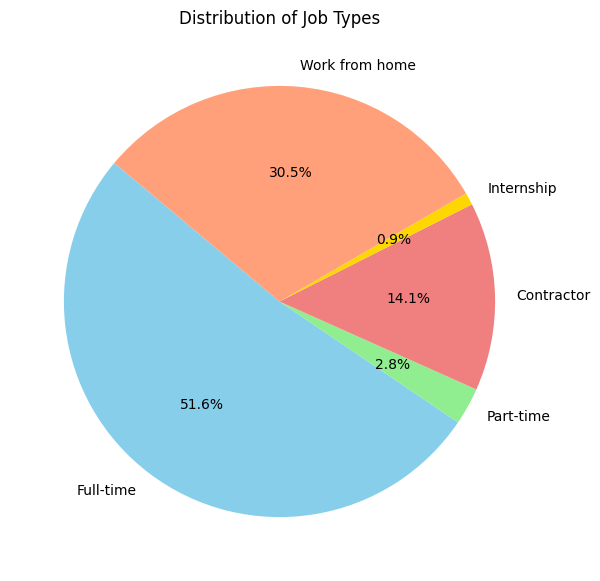

In [22]:
# Pie Chart: Distribution of job types
job_types_to_display = ["Full-time", "Part-time", "Contractor", "Internship", "Work from home"]
job_types_values = [job_attributes_counts[job_type] for job_type in job_types_to_display]

plt.figure(figsize=(10, 7))
plt.pie(job_types_values, labels=job_types_to_display, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen', 'lightcoral', 'gold', 'lightsalmon'])
plt.title('Distribution of Job Types')
plt.show()